In [60]:
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
from scipy.interpolate import make_interp_spline
import sys
import re
from scipy.interpolate import griddata


In [61]:
df_pdr_sim = pd.read_csv('../validation/pdr_gueglimo.csv')
df_latency_sim = pd.read_csv('../validation/latency_gueglimo.csv')
df_avg_energy_consumption_sim = pd.read_csv('../validation/avg_energy_consumption_gueglimo.csv')


df_pdr_testbed = pd.read_csv('../validation/pdr_testbed.csv')
df_latency_testbed = pd.read_csv('../validation/latency_testbed.csv')
df_avg_energy_consumption_testbed = pd.read_csv('../validation/avg_energy_consumption_testbed.csv')


df_latency_sim.drop(4, inplace=True)
df_latency_testbed.drop(4, inplace=True)


# Helper Function

In [62]:
my_label = "Our Work"
comparator_simulation_label = r" Gueglimo $ \emph{et al}$ [14]"
comparator_testbed_label = r"Experimental Testbed [14]"


plt.rcParams.update({
    # Typography
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,

    # If LaTeX is available, keep this True; otherwise set False
    'text.usetex': True,

    # Figure/export
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,

    # Axes appearance
    'axes.linewidth': 0.8,
    'axes.grid': False,
    'grid.alpha': 0.0,

    # Ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,

    # Legend
    'legend.frameon': True,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',

    'hatch.linewidth': 0.5,
})


def evaluate_error(sim, ana, threshold_pct, labels=None):
    """
    Compare simulated values to analytical values using relative error.

    Parameters
    ----------
    sim : array-like
        Simulated results (e.g., delivery ratios for different N).
    ana : array-like
        Analytical reference values (must have same length as sim).
    threshold_pct : float
        Acceptable relative error in percent (e.g., 2.0 for ±2%).
    labels : list of str, optional
        Descriptions for each data point (e.g., "N=10", "N=20").
        If None, index numbers are used.

    Prints
    ------
    - Per-point comparison: sim, ana, relative error (%), pass/fail.
    - Overall statistics: MAPE, RMSE (of relative errors), max error,
      and a final verdict if all points passed.
    """
    sim = np.asarray(sim, dtype=float)
    ana = np.asarray(ana, dtype=float)

    if len(sim) != len(ana):
        raise ValueError("sim and ana must have the same length.")

    if labels is None:
        labels = [f"Point {i}" for i in range(len(sim))]

    # Avoid division by zero (rare for delivery ratio / energy)
    with np.errstate(divide='ignore', invalid='ignore'):
        rel_errors = np.where(ana != 0, (sim - ana) / ana * 100, np.nan)
        abs_errors = sim - ana

    # Flag if analytical value is zero -> can't compute relative error
    zero_ana_mask = (ana == 0)
    if np.any(zero_ana_mask):
        print("Warning: Some analytical values are zero. Relative error set to NaN.")

    # Per-point check
    print(f"{'Label':<12} {'Sim':<10} {'Ana':<10} {'Rel.Err%':<10} {'Pass?':<8}")
    print("-" * 52)
    all_pass = True
    for i, lab in enumerate(labels):
        if np.isnan(rel_errors[i]):
            status = "N/A"
        else:
            status = "PASS" if abs(rel_errors[i]) <= threshold_pct else "FAIL"
            if status == "FAIL":
                all_pass = False
        print(f"{lab:<12} {sim[i]:<10.4f} {ana[i]:<10.4f} {rel_errors[i]:<10.2f} {status:<8}")

    print("\n--- Overall Statistics ---")
    valid = ~np.isnan(rel_errors)
    if np.any(valid):
        mape = np.mean(np.abs(rel_errors[valid]))
        rmse_rel = np.sqrt(np.mean(rel_errors[valid] ** 2))
        max_abs_rel = np.max(np.abs(rel_errors[valid]))
        print(f"MAPE (Mean Absolute Percentage Error) : {mape:.2f} %")
        print(f"RMSE of Relative Error                : {rmse_rel:.2f} %")
        print(f"Max Absolute Relative Error           : {max_abs_rel:.2f} %")
    else:
        print("No valid relative errors to compute (all ana are zero).")

    print(f"\nAll points within ±{threshold_pct}% threshold? {'Yes' if all_pass else 'No'}")
    return all_pass, rel_errors, abs_errors

def set_ieee_style(usetex=True, backend=None):
    """
    Apply rcParams and style sheet to mimic an IEEE pgfplots figure.
    
    Parameters
    ----------
    usetex : bool
        Use LaTeX for text rendering (requires a working LaTeX installation).
    backend : str or None
        Matplotlib backend. If 'pgf', the output can be saved as .pgf for
        direct inclusion in LaTeX documents (requires 'pgf' package).
    """
    plt.style.use('seaborn-v0_8-paper')  # clean base style

    rc = {
        # Typography (IEEE standard sizes)
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
        'font.size': 8,                # base font size (8pt for IEEE)
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,

        'text.usetex': usetex,
        'text.latex.preamble': r'\usepackage{newtxtext,newtxmath}',  # Times math

        # Figure dimensions for single-column IEEE (3.5 in width)
        'figure.dpi': 300,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,

        # Axes: full box (pgfplots default)
        'axes.linewidth': 0.6,
        'axes.grid': False,
        'axes.spines.top': True,
        'axes.spines.right': True,

        # Grid appearance (minor y grid as in pgfplots)
        'grid.alpha': 0.3,
        'grid.linestyle': ':',
        'grid.linewidth': 0.4,

        # Ticks (inward, pgfplots style)
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.size': 3.5,
        'ytick.major.size': 3.5,
        'xtick.minor.size': 2.0,
        'ytick.minor.size': 2.0,
        'xtick.major.width': 0.6,
        'ytick.major.width': 0.6,
        'xtick.minor.width': 0.5,
        'ytick.minor.width': 0.5,
        'xtick.top': True,
        'ytick.right': True,

        # Legend: thin black border, no fill (pgfplots legend style)
        'legend.frameon': True,
        'legend.edgecolor': 'black',
        'legend.fancybox': False,
        'legend.framealpha': 1.0,
        'legend.facecolor': 'white',   # or 'none' if you prefer transparent

        # Lines and markers
        'lines.linewidth': 0.8,
        'lines.markersize': 4,
        'lines.markeredgewidth': 0.6,
        'hatch.linewidth': 0.5,
    }

    plt.rcParams.update(rc)

    # Optionally switch to PGF backend for direct .pgf output
    if backend == 'pgf':
        plt.switch_backend('pgf')
        plt.rcParams.update({
            'pgf.texsystem': 'pdflatex',
            'pgf.rcfonts': False,
        })

def set_ieee_subfigure_style(usetex=True):
    """
    Apply larger font sizes suitable for a subfigure (~2 inches wide).
    """
    plt.style.use('seaborn-v0_8-paper')

    rc = {
        # Typography – increased by ~2 pt relative to full-column style
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
        'font.size': 13,               # base: 10 pt (was 8)
        'axes.labelsize': 10,
        'axes.titlesize': 13,
        'legend.fontsize': 12,          # legend: 9 pt (was 7)
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,

        'text.usetex': usetex,
        'text.latex.preamble': r'\usepackage{newtxtext,newtxmath}',

        'figure.dpi': 300,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,

        # Axes – slightly thicker lines for visibility at smaller size
        'axes.linewidth': 0.8,
        'axes.grid': False,
        'axes.spines.top': True,
        'axes.spines.right': True,

        'grid.alpha': 0.3,
        'grid.linestyle': ':',
        'grid.linewidth': 0.5,

        # Ticks – larger to match thicker lines
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.size': 4.0,       # was 3.5
        'ytick.major.size': 4.0,
        'xtick.minor.size': 2.5,
        'ytick.minor.size': 2.5,
        'xtick.major.width': 0.8,
        'ytick.major.width': 0.8,
        'xtick.minor.width': 0.6,
        'ytick.minor.width': 0.6,
        'xtick.top': True,
        'ytick.right': True,

        # Legend – thin black border, no fill
        'legend.frameon': True,
        'legend.edgecolor': 'black',
        'legend.fancybox': False,
        'legend.framealpha': 1.0,
        'legend.facecolor': 'none',    # transparent

        # Lines and markers – slightly larger for clarity
        'lines.linewidth': 1.0,
        'lines.markersize': 5,         # was 4
        'lines.markeredgewidth': 0.8,
        'hatch.linewidth': 0.6,
    }

    plt.rcParams.update(rc)


def apply_pgfplots_style(ax, xlim=None, ylim=None, y_pad=0.08):
    """
    Tune a matplotlib Axes to look like a pgfplots axis.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
    xlim, ylim : tuple, optional
        Axis limits. If None, limits are taken from the data.
    y_pad : float
        Fractional padding for the y‑axis (mimics `enlarge y limits`).
    """
    # Minor ticks on both axes
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Major tick parameters (already set globally, but ensure per-axis)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.tick_params(which='major', length=3.5, width=0.6)
    ax.tick_params(which='minor', length=2.0, width=0.5)

    # Grid: only y axis (typical for this kind of plot), minor grid lines optional
    ax.grid(axis='y', which='major', linestyle=':', linewidth=0.4, color='0.7')
    # Uncomment the next line to add minor y grid (very pgfplots-like)
    # ax.grid(axis='y', which='minor', linestyle=':', linewidth=0.3, color='0.85')

    # Adjust limits with automatic padding (like enlarge y limits)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is None:
        ymin, ymax = ax.get_ylim()
        pad = (ymax - ymin) * y_pad
        ax.set_ylim(ymin - pad, ymax + pad)
    else:
        ax.set_ylim(ylim)

    # Legend style (if legend exists, set border and no fill)
    legend = ax.get_legend()
    if legend is not None:
        legend.get_frame().set_linewidth(0.5)
        legend.get_frame().set_facecolor('none')  # transparent fill


# ---------------------- Your original function, enhanced -----------------
# (keep your labels; they already use LaTeX commands like \emph{et al})
my_label = r"Our Work"
comparator_simulation_label = r"Gueglimo \emph{et al} [14]"   # corrected typo
comparator_testbed_label = r"Testbed [14]"


def plot_data(y, y_comparation, y_testbed):
    n_nodes = [1, 5, 10, 20, 30, 40, 50]

    # Create figure with exact IEEE single‑column width
    fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)

    # ---- Plot the three curves ----
    # Simulation comparison (dash-dot)
    ax.plot(n_nodes, y_comparation,
            color='k', linestyle='-.', marker='o',
            markersize=4, markerfacecolor='white', markeredgewidth=0.6,
            linewidth=0.8, markevery=1,
            label=comparator_simulation_label)

    # Testbed comparison (dashed)
    ax.plot(n_nodes, y_testbed,
            color='k', linestyle='--', marker='v',
            markersize=4, markerfacecolor='white', markeredgewidth=0.6,
            linewidth=0.8, markevery=1,
            label=comparator_testbed_label)

    # Our work (solid)
    ax.plot(n_nodes, y,
            color='black', linestyle='-', marker='D',
            markersize=4, markerfacecolor='white', markeredgewidth=0.6,
            linewidth=0.8, markevery=1,
            label=my_label)

    # ---- Apply pgfplots-like finishing touches ----
    # Choose a suitable x axis (number of nodes)
    ax.set_xlabel("Number of Nodes")
    ax.set_xlim(0, 52)   # a little padding beyond the data

    # Apply automatic y padding and styling
    apply_pgfplots_style(ax, xlim=(0, 52), y_pad=0.08)

    # Place legend: try upper right inside; if it overlaps data, move to best
    ax.legend(loc='best', frameon=True, fontsize=7,
              edgecolor='black', facecolor='none')

    return fig, ax


def plot_data(y, y_comparation, y_testbed, degree = 2):
    n_nodes = np.array([1, 5, 10, 20, 30, 40, 50])

    # Create figure with exact IEEE single-column width
    fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)

    # Dense x-axis for smooth fitted curves
    x_smooth = np.linspace(n_nodes.min(), n_nodes.max(), 100)

    # ===== Polynomial fitting =====
    

    
    # ===== Plot fitted curves =====

    if degree == -1:
        ax.plot(n_nodes, y_comparation,
            color='k', linestyle='-.', marker='o',
            markersize=4, markerfacecolor='white', markeredgewidth=0.6,
            linewidth=0.8, markevery=1,
            label=comparator_simulation_label)

        # Testbed comparison (dashed)
        ax.plot(n_nodes, y_testbed,
                color='k', linestyle='--', marker='v',
                markersize=4, markerfacecolor='white', markeredgewidth=0.6,
                linewidth=0.8, markevery=1,
                label=comparator_testbed_label)

        # Our work (solid)
        ax.plot(n_nodes, y,
                color='black', linestyle='-', marker='D',
                markersize=4, markerfacecolor='white', markeredgewidth=0.6,
                linewidth=0.8, markevery=1,
                label=my_label)
    else:
        poly_comp = np.poly1d(
            np.polyfit(n_nodes, y_comparation, degree)
        )

        poly_testbed = np.poly1d(
            np.polyfit(n_nodes, y_testbed, degree)
        )

        poly_ours = np.poly1d(
            np.polyfit(n_nodes, y, degree)
        )

        # Simulation comparison
        ax.plot(
            x_smooth,
            poly_comp(x_smooth),
            color='k',
            linestyle='-.',
            linewidth=0.8,
            label=comparator_simulation_label
        )

        # Testbed comparison
        ax.plot(
            x_smooth,
            poly_testbed(x_smooth),
            color='k',
            linestyle='--',
            linewidth=0.8,
            label=comparator_testbed_label
        )

        # Our work
        ax.plot(
            x_smooth,
            poly_ours(x_smooth),
            color='black',
            linestyle='-',
            linewidth=0.8,
            label=my_label
        )

    # ===== Plot original markers =====

    ax.plot(
        n_nodes,
        y_comparation,
        linestyle='None',
        marker='o',
        color='k',
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    ax.plot(
        n_nodes,
        y_testbed,
        linestyle='None',
        marker='v',
        color='k',
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    ax.plot(
        n_nodes,
        y,
        linestyle='None',
        marker='D',
        color='black',
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    # ===== Formatting =====

    ax.set_xlabel("Number of Nodes")
    ax.set_xlim(0, 52)

    apply_pgfplots_style(
        ax,
        xlim=(0, 52),
        y_pad=0.08
    )

    ax.legend(
        loc='best',
        frameon=True,
        fontsize=7,
        edgecolor='black',
        facecolor='none'
    )

    return fig, ax

# Pullup the Data

In [63]:
# n_nodes = [1, 5, 10, 20, 30, 40, 50]
# # n_nodes = range(5, 55, 5)

# labels = [f'N = {i}' for i in n_nodes]
# latency = []
# total_latency = []
# latency_data = []
# pdr = []
# metrics = []
# hidden_nodes = []
# avg_energies = []

# for idx, filename in enumerate(sorted(os.listdir('output')[:7])):
#     path = './validation/data/' + filename + '/Period-1'
#     path = './output/' + filename + '/Period-1'

#     print(path)
# # for idx, filename in enumerate(sorted(os.listdir('./output')[:7])):
# #     path = './output/' + filename + '/Period-1'

#     with open(path + '/latency_results.pkl', 'rb') as file:
#         latency_data = pickle.load(file)
#         # print(data)
#         total_latency.append(latency_data['total_latency'])

#     with open(path + '/metrics_results.pkl', 'rb') as file:
#         metrics = pickle.load(file)
#         # print(data)
#         pdr.append(metrics['pdr'])
#         latency.append(metrics['avg_latency_ms'])

#     with open(path + '/transmission_results.pkl', 'rb') as file:
#         transmission = pickle.load(file)
#         hidden_nodes.append(transmission['hidden_node_detected'])

#     with open(path + '/energy_consumption_results.pkl', 'rb') as file:
#         energies = pickle.load(file)

#         total = 0
#         for key, val in energies.items():
#             # if key =='sleep': continue
#             total += val * 1e3

#         avg_energies.append(total/(len(energies.keys())))   

# print("Metrics Lookup")
# print(latency_data)
# print(metrics)
# print(transmission)
# print(energies)

# set_ieee_style(usetex=True)


# Pullup the Data - 2

In [64]:
n_nodes = [1, 5, 10, 20, 30, 40, 50]
labels = [f'N = {i}' for i in n_nodes]
# labels = [f'N = {i}' for i in n_nodes]

# ---------- Configuration ----------
OUTPUT_BASE = "../output/Model Validation-3 (PDR, Latency, Energy)/"

# OUTPUT_BASE = "./output/Center_BS_ITU_R_1411_No Sensor and Logging/"

METRICS = [
    'pdr',
    'total_packet_sent',
    'collision_failure',
    'avg_energy_consumption',
    'avg_latency_ms',
    'alive_nodes',
    'channel_busy_failure',
    'hidden_node_detected',
    'total_latency',
    'throughput_kbps',
    'throughput_bps',
    'normalized_throughput',
    'total_backoffs'
]

def parse_n_l_from_trial(path):
    """
    Parse N and L from a trial folder name like:
    TRIAL - 1 - (22-06-2026) - Ideal_DirectUnslottedCSMA_N10_L10
    """

    # First try YAML file
    for f in os.listdir(path):
        if f.endswith(".yaml"):
            match = re.search(r'_N(\d+)_L(\d+)', f, re.IGNORECASE)
            if match:
                return int(match.group(1)), int(match.group(2))

    # Fallback: parse folder name
    folder_name = os.path.basename(path)

    match = re.search(r'_N(\d+)_L(\d+)', folder_name, re.IGNORECASE)
    if match:
        return int(match.group(1)), int(match.group(2))

    return None, None


def get_metric_from_trial(trial_path, metric_name):
    """
    Returns the aggregated metric for one trial.
    Assumes the trial folder contains subfolders 'Period-0', 'Period-1', ...
    For each round, load the pickle files and collect the metric.
    If metric_name is 'avg_energy_consumption', we compute it from the energy file.
    """
    periods = sorted([d for d in os.listdir(trial_path)
                      if os.path.isdir(os.path.join(trial_path, d)) and d.startswith("Period-")])

    # For energy consumption, we need to compute per period
    if metric_name == 'avg_energy_consumption':
        total_energy_per_period = []
        for period in periods:
            energy_file = os.path.join(trial_path, period, 'energy_consumption_results.pkl')
            if os.path.exists(energy_file):
                with open(energy_file, 'rb') as f:
                    energies = pickle.load(f)
                total = sum(v * 1e3 for k, v in energies.items() )  # J to mJ?
                total_energy_per_period.append(total / (len(energies) ))  # per-node average?
        if total_energy_per_period:
            return np.mean(total_energy_per_period)
        else:
            return np.nan

    # For all other metrics stored in metrics_results.pkl or transmission_results.pkl
    values = []
    for period in periods:
        # metrics
        metrics_file = os.path.join(trial_path, period, 'metrics_results.pkl')
        if os.path.exists(metrics_file):
            with open(metrics_file, 'rb') as f:
                data = pickle.load(f)
                if metric_name in data:
                    # if metric_name == "avg_latency_ms":
                    #     values.append(float(data[metric_name]) * float(data['alive_nodes']))

                    # else:
                    #     values.append(float(data[metric_name]))

                    values.append(float(data[metric_name]))

        # transmission results
        trans_file = os.path.join(trial_path, period, 'transmission_results.pkl')
        if os.path.exists(trans_file):
            with open(trans_file, 'rb') as f:
                data = pickle.load(f)
                if metric_name in data:
                    
                    values.append(float(data[metric_name]))

    if values:
        # The user's original aggregation: for PDR they average over rounds,
        # for alive_nodes they take the last round's value.
        # Here we just return the overall mean; adjust if needed.
        if metric_name == 'alive_nodes':
            return values[-1]  # last round only
        return np.mean(values)
    else:
        return np.nan

def collect_data():
    """
    Returns a dict: data[N][L] = list of metric_values (one per replication).
    """
    results = {}
    for trial_name in os.listdir(OUTPUT_BASE):
        trial_path = os.path.join(OUTPUT_BASE, trial_name)
        if not os.path.isdir(trial_path) or not trial_name.startswith("TRIAL"):
            continue

        N, L = parse_n_l_from_trial(trial_path)
        if N is None or L is None:
            continue

        # Get all metrics for this trial
        metrics_vals = {}
        for m in METRICS:
            val = get_metric_from_trial(trial_path, m)
            if not np.isnan(val):
                metrics_vals[m] = val

        key = (N, L)
        if key not in results:
            results[key] = {m: [] for m in METRICS}
        for m, v in metrics_vals.items():
            results[key][m].append(v)

    return results


OUTPUT_BASE = "../output/"
OUTPUT_BASE = "../data/Model Validation - 3 (PDR, Latency, Energy)/"

results = collect_data()
results = dict(sorted(results.items()))
temp = {metric: [] for metric in METRICS}

for key, val in results.items():
    for metric in val.keys():
        temp[metric].append(np.mean(val[metric]))
    # print(f"{key}: {np.mean(val['pdr'])}")


temp['total_backoffs'] = [i/n_nodes[idx] for idx, i in enumerate(temp['total_backoffs'])]
# temp['pdr'] = [i * 100 for i in temp['pdr']]
# results[(1,10)]

/mnt/Program/All/WSN-Simulator-for-IEEE-802.15.4-Network/.env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/Program/All/WSN-Simulator-for-IEEE-802.15.4-Network/.env/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


# PDR

<>:11: SyntaxWarning: invalid escape sequence '\%'
<>:11: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_3969629/1965167168.py:11: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel("PDR [\%]")


Label        Sim        Ana        Rel.Err%   Pass?   
----------------------------------------------------
N = 1        100.0000   85.3160    17.21      FAIL    
N = 5        40.0000    41.8216    -4.36      FAIL    
N = 10       22.2222    21.9331    1.32       PASS    
N = 20       13.3333    10.4089    28.10      FAIL    
N = 30       9.6667     6.5056     48.59      FAIL    
N = 40       7.2500     4.4610     62.52      FAIL    
N = 50       6.0000     3.5316     69.89      FAIL    

--- Overall Statistics ---
MAPE (Mean Absolute Percentage Error) : 33.14 %
RMSE of Relative Error                : 41.85 %
Max Absolute Relative Error           : 69.89 %

All points within ±2.0% threshold? No


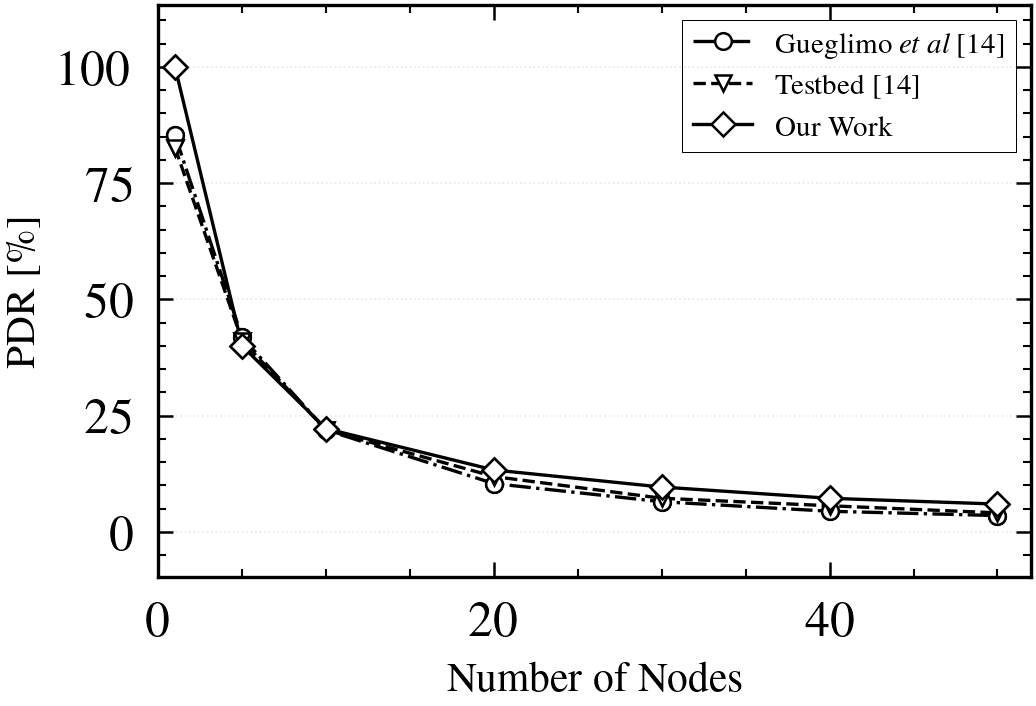

In [65]:
# fig, ax = plot_data(pdr, df_pdr_sim['y'], df_pdr_testbed['y'])
# evaluate_error(pdr, df_pdr_sim['y'], threshold_pct=2.0, labels=labels)
# ax.set_ylabel("PDR [\%]")
# fig.savefig(f'....../validation/results/PDR.png', dpi=600, bbox_inches='tight')


# plt.show()
set_ieee_subfigure_style()
fig, ax = plot_data(temp['pdr'], df_pdr_sim['y'], df_pdr_testbed['y'], degree=-1)
evaluate_error(temp['pdr'], df_pdr_sim['y'], threshold_pct=2.0, labels=labels)
ax.set_ylabel("PDR [\%]")
fig.savefig(f'../validation/results/PDR.png', dpi=600, bbox_inches='tight')


plt.show()

# Latency

Label        Sim        Ana        Rel.Err%   Pass?   
----------------------------------------------------
N = 1        7.1148     9.2007     -22.67     FAIL    
N = 5        9.0524     10.9572    -17.38     FAIL    
N = 10       8.7954     13.1877    -33.31     FAIL    
N = 20       9.7165     16.1710    -39.91     FAIL    
N = 30       10.2982    19.6283    -47.53     FAIL    
N = 40       10.3056    22.4442    -54.08     FAIL    
N = 50       10.3951    20.6041    -49.55     FAIL    

--- Overall Statistics ---
MAPE (Mean Absolute Percentage Error) : 37.78 %
RMSE of Relative Error                : 39.93 %
Max Absolute Relative Error           : 54.08 %

All points within ±2.0% threshold? No


(False,
 array([-22.67185473, -17.38450684, -33.3061987 , -39.91378872,
        -47.53363216, -54.08337067, -49.54826348]),
 array([ -2.0859792 ,  -1.90486371,  -4.39233234,  -6.45446026,
         -9.33002148, -12.13860039, -10.20896841]))

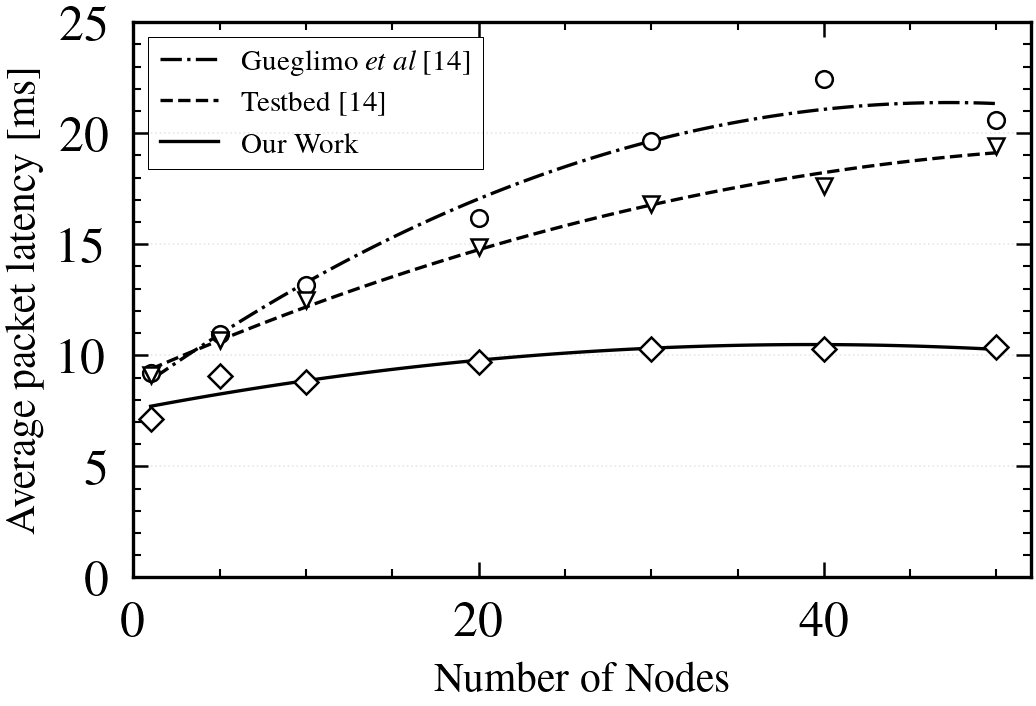

In [66]:
# fig, ax = plot_data(latency, df_latency_sim['y'], df_latency_testbed['y'])
# ax.set_ylim([0,50])
# ax.set_ylabel("Average packet latency [ms]")
# fig.savefig(f'./validation/results/latency.png', dpi=600, bbox_inches='tight')

# evaluate_error(latency, df_latency_sim['y'], threshold_pct=2.0, labels=labels)

fig, ax = plot_data(temp['avg_latency_ms'], df_latency_sim['y'], df_latency_testbed['y'], degree=2)
ax.set_ylim([0,25])
ax.set_ylabel("Average packet latency [ms]")
fig.savefig(f'../validation/results/latency.png', dpi=600, bbox_inches='tight')

evaluate_error(temp['avg_latency_ms'], df_latency_sim['y'], threshold_pct=2.0, labels=labels)

# Avg Energy Consumption

Label        Sim        Ana        Rel.Err%   Pass?   
----------------------------------------------------
N = 1        0.0678     0.3086     -78.04     FAIL    
N = 5        0.3134     0.5594     -43.97     FAIL    
N = 10       0.5851     0.8768     -33.27     FAIL    
N = 20       1.1376     1.4489     -21.49     FAIL    
N = 30       1.6547     2.0250     -18.29     FAIL    
N = 40       2.2044     2.5971     -15.12     FAIL    
N = 50       2.7264     3.1732     -14.08     FAIL    

--- Overall Statistics ---
MAPE (Mean Absolute Percentage Error) : 32.04 %
RMSE of Relative Error                : 38.46 %
Max Absolute Relative Error           : 78.04 %

All points within ±5.0% threshold? No


(0.0, 5.0)

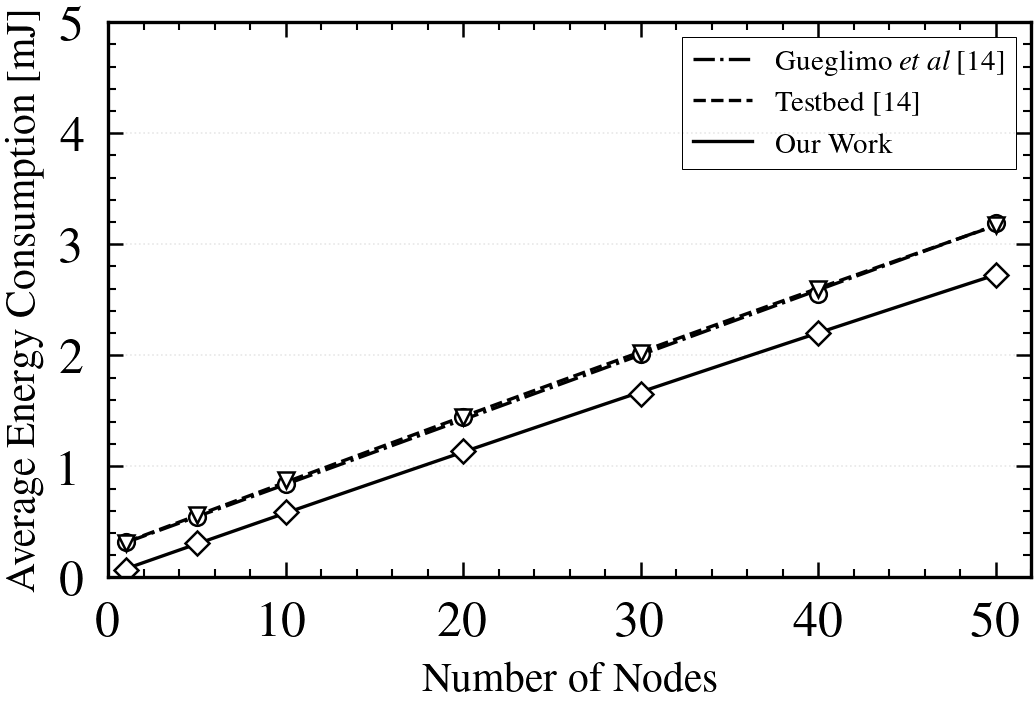

In [67]:
n_nodes = [1, 5, 10, 20, 30, 40, 50]

fig, ax = plot_data(temp['avg_energy_consumption'], df_avg_energy_consumption_sim['y'], df_avg_energy_consumption_testbed['y'])
evaluate_error(temp['avg_energy_consumption'], df_avg_energy_consumption_testbed['y'], threshold_pct=5.0, labels=labels)
ax.set_ylabel("Average Energy Consumption [mJ]")
fig.savefig(f'../validation/results/energy_consumed.png', dpi=600, bbox_inches='tight')

ax.set_ylim([0, 5])

# Simulation Validation

In [68]:
OUTPUT_BASE = "./output/Model Validation (Normalized Throughput)/"
results = collect_data()
results = dict(sorted(results.items()))
temp2 = {metric: [] for metric in METRICS}

for key, val in results.items():
    for metric in val.keys():
        temp2[metric].append(np.mean(val[metric]))
n_nodes = range(5, 55, 5)


n_metrics = len(temp2.keys()) 

fig, axs = plt.subplots(int(np.ceil(n_metrics / 3)), 3 , figsize=(3.5 * 3, 2.4 * int(np.ceil(n_metrics / 3))))

row = 0 
col = 0
for idx, metric in enumerate(temp2.keys()):
    axs[row, col].plot(
        n_nodes,
        temp2[metric],
        marker='x',
        label='Our Work'
    )
    axs[row, col].set_title(metric)

    if metric == 'normalized_throughput':
        axs[row, col].set_ylim([0, 1])

    col += 1

    if col + 1 > 3:
        row += 1
        col = 0

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: './output/Model Validation (Normalized Throughput)/'

# Throughput - 1

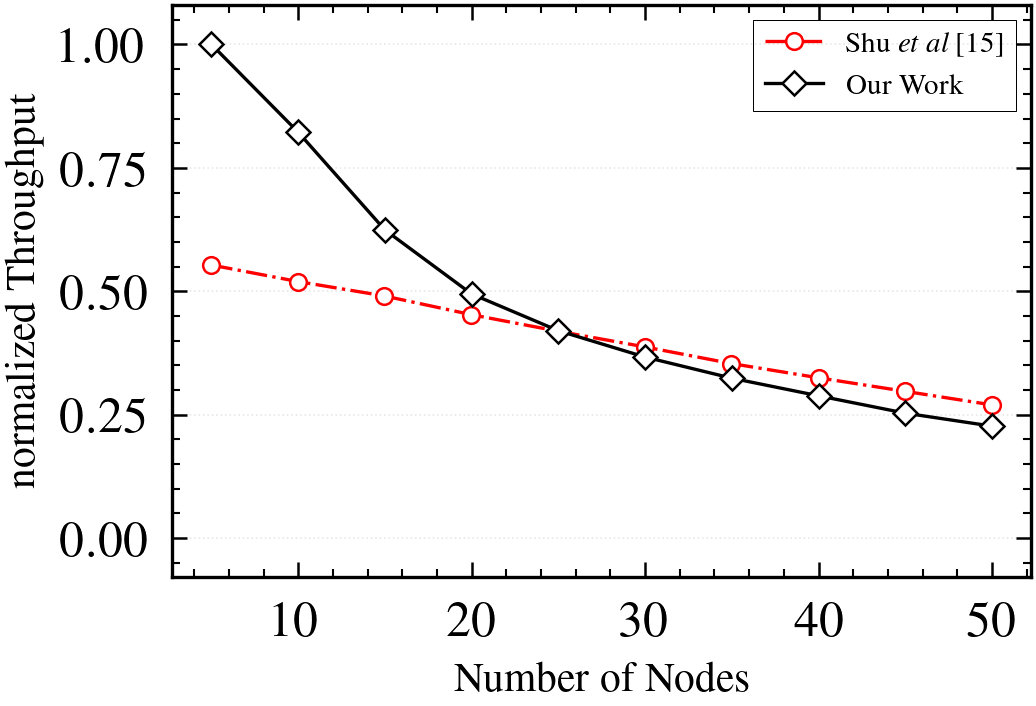

In [ ]:
df_throughput = pd.read_csv('./validation/throughput_shu.csv')

fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)

# ---- Plot the three curves ----
# Simulation comparison (dash-dot)
ax.plot(df_throughput['x'], df_throughput['y'],
        color='r', linestyle='-.', marker='o',
        markersize=4, markerfacecolor='white', markeredgewidth=0.6,
        linewidth=0.8, markevery=1,
        label=r'Shu $\emph{et al}$ [15]')


# Our work (solid)
ax.plot(n_nodes, temp2['normalized_throughput'],
        color='black', linestyle='-', marker='D',
        markersize=4, markerfacecolor='white', markeredgewidth=0.6,
        linewidth=0.8, markevery=1,
        label=my_label)

# ---- Apply pgfplots-like finishing touches ----
# Choose a suitable x axis (number of nodes)
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("normalized Throughput")
fig.savefig(f'./validation/results/Normalized_throughput.png', dpi=600, bbox_inches='tight')
# ax.set_xlim(0, 52)   # a little padding beyond the data
ax.set_ylim(0, 1)
# Apply automatic y padding and styling
apply_pgfplots_style(ax, y_pad=0.08)

# ax.hlines(0.01, 0, 225, linestyle='dotted', color='k')
# Place legend: try upper right inside; if it overlaps data, move to best
ax.legend(loc='best', frameon=True, fontsize=7,
            edgecolor='black', facecolor='none')

# Throughput - 2

ValueError: x and y must have same first dimension, but have shapes (10,) and (7,)

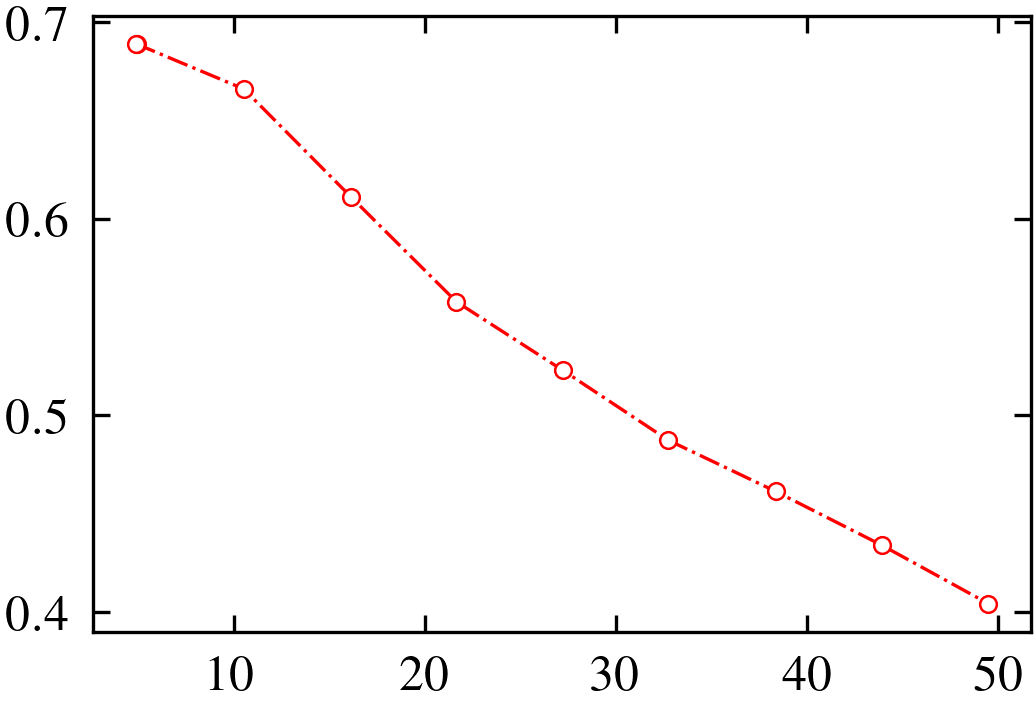

In [ ]:
df_throughput = pd.read_csv('./validation/throughput_luong.csv')

OUTPUT_BASE = "./output/"
results = collect_data()
results = dict(sorted(results.items()))
temp2 = {metric: [] for metric in METRICS}

for key, val in results.items():
    for metric in val.keys():
        temp2[metric].append(np.mean(val[metric]))
n_nodes = range(5, 55, 5)


fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)

# ---- Plot the three curves ----
# Simulation comparison (dash-dot)
ax.plot(df_throughput['x'], df_throughput['y'],
        color='r', linestyle='-.', marker='o',
        markersize=4, markerfacecolor='white', markeredgewidth=0.6,
        linewidth=0.8, markevery=1,
        label=r'Luong $\emph{et al}$ [15]')


# Our work (solid)
ax.plot(n_nodes, temp2['normalized_throughput'],
        color='black', linestyle='-', marker='D',
        markersize=4, markerfacecolor='white', markeredgewidth=0.6,
        linewidth=0.8, markevery=1,
        label=my_label)

# ---- Apply pgfplots-like finishing touches ----
# Choose a suitable x axis (number of nodes)
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("normalized Throughput")
fig.savefig(f'./validation/results/Normalized_throughput.png', dpi=600, bbox_inches='tight')
# ax.set_xlim(0, 52)   # a little padding beyond the data
ax.set_ylim(0, 1)
# Apply automatic y padding and styling
apply_pgfplots_style(ax, y_pad=0.08)

# ax.hlines(0.01, 0, 225, linestyle='dotted', color='k')
# Place legend: try upper right inside; if it overlaps data, move to best
ax.legend(loc='best', frameon=True, fontsize=7,
            edgecolor='black', facecolor='none')
